# Notebook 02 — SentencePiece BPE Tokenizer (Stage 5)

Analyses the SentencePiece model and vocabulary artifacts from Stage 5, plus encoded pairs from Stage 6.

| Section | Topic |
|---------|-------|
| **A.1** | Load SPM & vocab · verify pinned token IDs |
| **A.2** | Vocabulary coverage per split |
| **A.3** | Tokenization examples |
| **A.4** | Fertility analysis |
| **A.5** | UNK (id=1) rate per split |
| **A.6** | Placeholder token usage |
| **A.7** | Token frequency distribution |
| **A.8** | Top-50 most frequent pieces |


In [1]:
# === SETUP: Imports, Paths, and Helpers ===

import json
import math
import random
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import sentencepiece as spm
from rich.console import Console
from rich.panel import Panel
from rich.table import Table
from rich import box

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
VIZ_DIR      = PROJECT_ROOT / 'notebooks' / 'visualizations'
VIZ_DIR.mkdir(parents=True, exist_ok=True)

SPM_MODEL      = ARTIFACT_DIR / 'stage5_spm.model'
SPM_VOCAB      = ARTIFACT_DIR / 'stage5_spm.vocab'
VOCAB_JSON     = ARTIFACT_DIR / 'stage6_vocab.json'
IDX2WORD_JSON  = ARTIFACT_DIR / 'stage6_idx2word.json'
STAGE6_STATS   = ARTIFACT_DIR / 'stage6_stats.json'
TRAIN_JSONL    = ARTIFACT_DIR / 'stage6_train_ids.jsonl'
VAL_JSONL      = ARTIFACT_DIR / 'stage6_val_ids.jsonl'
TEST_JSONL     = ARTIFACT_DIR / 'stage6_test_ids.jsonl'

# Pinned token IDs
PAD_ID, UNK_ID, SOS_ID, EOS_ID = 0, 1, 2, 3

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False, 'font.size': 11,
})
sns.set_palette('muted')
console = Console(highlight=True)
random.seed(42)

def _require(path: Path, label: str = '') -> bool:
    if path.exists():
        return True
    console.print(Panel(
        f'[bold red]File not found:[/bold red] {path}\n'
        f'[yellow]Run phase1.py to generate {label or path.name}.[/yellow]',
        title='⚠  Missing Artefact', border_style='red'
    ))
    return False

def _load_jsonl(path: Path, max_lines: int = None) -> list:
    records = []
    with open(path, encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_lines and i >= max_lines:
                break
            records.append(json.loads(line))
    return records

def _save_fig(fig, name: str):
    out = VIZ_DIR / f'{name}.png'
    fig.savefig(out, bbox_inches='tight', dpi=150)
    console.print(f'[green]Saved[/green] → {out}')

console.print(Panel('[bold green]Setup complete[/bold green]\n'
    f'ARTIFACT_DIR = {ARTIFACT_DIR}',
    title='Notebook 02 — Tokenizer Analysis', border_style='green'))


╭─────────────────────────────────────── Notebook 02 — Tokenizer Analysis ────────────────────────────────────────╮
│ Setup complete                                                                                                  │
│ ARTIFACT_DIR = C:\git\nlp-final-project\artifacts                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## A.1 — Load SPM & Vocab · Verify Pinned Token IDs

In [2]:
# === SECTION A.1: Load SPM, vocab.json, idx2word.json; verify pinned IDs ===

if not (_require(SPM_MODEL, 'stage5_spm.model') and
        _require(VOCAB_JSON, 'stage6_vocab.json') and
        _require(IDX2WORD_JSON, 'stage6_idx2word.json')):
    raise SystemExit('Missing tokenizer artifacts')

sp = spm.SentencePieceProcessor()
sp.Load(str(SPM_MODEL))

with open(VOCAB_JSON, encoding='utf-8') as f:
    vocab = json.load(f)   # token_string -> id
with open(IDX2WORD_JSON, encoding='utf-8') as f:
    idx2word = json.load(f)  # id_string -> token_string

console.print(f'SPM vocab size: {sp.GetPieceSize()}')
console.print(f'vocab.json size: {len(vocab)}')
console.print(f'idx2word.json size: {len(idx2word)}')

# ── Verify pinned IDs ─────────────────────────────────────────────────────
PINNED = {'<pad>': 0, '<unk>': 1, '<sos>': 2, '<eos>': 3}
USER_DEFINED = ['▁__url__', '▁__path__', '▁__ip__', '▁__eot__', '▁__user__']

t = Table(title='Pinned Special Token ID Verification', box=box.ROUNDED)
t.add_column('Token', style='cyan')
t.add_column('Expected ID', justify='right')
t.add_column('SPM id', justify='right')
t.add_column('vocab.json id', justify='right')
t.add_column('Status', justify='center')

all_pass = True
for tok, expected_id in PINNED.items():
    spm_id   = sp.piece_to_id(tok)
    vocab_id = vocab.get(tok, 'MISSING')
    ok = (spm_id == expected_id and vocab_id == expected_id)
    status = '[bold green]PASS[/bold green]' if ok else '[bold red]FAIL[/bold red]'
    if not ok: all_pass = False
    t.add_row(tok, str(expected_id), str(spm_id), str(vocab_id), status)
console.print(t)

# User-defined tokens — IDs vary, just look them up
t2 = Table(title='User-Defined Special Tokens (IDs vary)', box=box.ROUNDED)
t2.add_column('Token', style='cyan')
t2.add_column('SPM id', justify='right')
t2.add_column('vocab.json id', justify='right')
t2.add_column('Single-piece?', justify='center')
for tok in USER_DEFINED:
    spm_id   = sp.piece_to_id(tok)
    vocab_id = vocab.get(tok, 'MISSING')
    plain    = tok.lstrip('▁')   # '▁__url__' -> '__url__' (real-world text form)
    ctx_pcs  = sp.encode_as_pieces(f'test {plain} text')
    single   = '[green]YES[/green]' if tok in ctx_pcs else f'[red]NO ({sp.encode_as_pieces(plain)})[/red]'
    t2.add_row(tok, str(spm_id), str(vocab_id), single)
console.print(t2)

# SPM piece round-trip for IDs 0-11
t3 = Table(title='SPM Piece Round-Trip (IDs 0–11)', box=box.SIMPLE_HEAD)
t3.add_column('ID', justify='right')
t3.add_column('piece')
t3.add_column('idx2word[id]')
for i in range(min(12, sp.GetPieceSize())):
    piece = sp.id_to_piece(i)
    i2w   = idx2word.get(str(i), '—')
    t3.add_row(str(i), piece, i2w)
console.print(t3)
    
if all_pass:
    console.print('[bold green]✓ All pinned token IDs verified successfully.[/bold green]')
else:
    console.print('[bold red]✗ Some pinned IDs failed — check pipeline config.[/bold red]')


SPM vocab size: 32000

vocab.json size: 32000

idx2word.json size: 32000

          Pinned Special Token ID Verification           
╭───────┬─────────────┬────────┬───────────────┬────────╮
│ Token │ Expected ID │ SPM id │ vocab.json id │ Status │
├───────┼─────────────┼────────┼───────────────┼────────┤
│ <pad> │           0 │      0 │             0 │  PASS  │
│ <unk> │           1 │      1 │             1 │  PASS  │
│ <sos> │           2 │      2 │             2 │  PASS  │
│ <eos> │           3 │      3 │             3 │  PASS  │
╰───────┴─────────────┴────────┴───────────────┴────────╯

        User-Defined Special Tokens (IDs vary)        
╭───────────┬────────┬───────────────┬───────────────╮
│ Token     │ SPM id │ vocab.json id │ Single-piece? │
├───────────┼────────┼───────────────┼───────────────┤
│ ▁__url__  │      4 │             4 │      YES      │
│ ▁__path__ │      5 │             5 │      YES      │
│ ▁__ip__   │      6 │             6 │      YES      │
│ ▁__eot__  │      7 │             7 │      YES      │
│ ▁__user__ │      8 │             8 │      YES      │
╰───────────┴────────┴───────────────┴───────────────╯

  SPM Piece Round-Trip (IDs   
            0–11)             
                              
  ID   piece       idx2word   
 ──────────────────────────── 
   0   <pad>       <pad>      
   1   <unk>       <unk>      
   2   <sos>       <sos>      
   3   <eos>       <eos>      
   4   ▁__url__    ▁__url__   
   5   ▁__path__   ▁__path__  
   6   ▁__ip__     ▁__ip__    
   7   ▁__eot__    ▁__eot__   
   8   ▁__user__   ▁__user__  
   9   ▁i          ▁i         
  10   ▁t          ▁t         
  11   ▁a          ▁a

✓ All pinned token IDs verified successfully.

## A.2 — Vocabulary Coverage

In [3]:
# === SECTION A.2: Piece-type breakdown + per-split vocab coverage ===

# ── Part 1: piece-type breakdown ─────────────────────────────────────────
n_vocab = sp.GetPieceSize()
n_special = n_word_initial = n_subword = 0
for i in range(n_vocab):
    piece = sp.id_to_piece(i)
    if piece.startswith('<') or piece.startswith('__'):
        n_special += 1
    elif piece.startswith('\u2581'):  # ▁
        n_word_initial += 1
    else:
        n_subword += 1

t = Table(title='Vocabulary Piece-Type Breakdown', box=box.ROUNDED)
t.add_column('Type', style='cyan')
t.add_column('Count', justify='right')
t.add_column('%', justify='right')
for label, n in [('Special (<...> / __...__)' , n_special),
                  ('Word-initial (▁)', n_word_initial),
                  ('Subword continuation', n_subword)]:
    t.add_row(label, f'{n:,}', f'{100*n/n_vocab:.1f}%')
t.add_row('[bold]Total[/bold]', f'[bold]{n_vocab:,}[/bold]', '[bold]100%[/bold]')
console.print(t)

# ── Part 2: per-split coverage ────────────────────────────────────────────
console.print('[bold]Computing per-split vocabulary coverage (may take a moment)...[/bold]')
all_ids = set(range(n_vocab))
split_files = [('train', TRAIN_JSONL), ('val', VAL_JSONL), ('test', TEST_JSONL)]

t2 = Table(title='Per-Split Vocabulary Coverage', box=box.ROUNDED)
t2.add_column('Split', style='cyan')
t2.add_column('Unique IDs Seen', justify='right')
t2.add_column('Coverage %', justify='right')
t2.add_column('Missing IDs', justify='right')
for split_name, fpath in split_files:
    if not fpath.exists():
        t2.add_row(split_name, 'MISSING', '—', '—')
        continue
    seen = set()
    with open(fpath, encoding='utf-8') as f:
        for line in f:
            rec = json.loads(line)
            seen.update(rec.get('ctx', []))
            seen.update(rec.get('resp', []))
    n_seen = len(seen & all_ids)
    cov = 100 * n_seen / n_vocab
    missing = n_vocab - n_seen
    t2.add_row(split_name, f'{n_seen:,}', f'{cov:.1f}%', f'{missing:,}')
console.print(t2)


       Vocabulary Piece-Type Breakdown        
╭───────────────────────────┬────────┬───────╮
│ Type                      │  Count │     % │
├───────────────────────────┼────────┼───────┤
│ Special (<...> / __...__) │     10 │  0.0% │
│ Word-initial (▁)          │ 23,571 │ 73.7% │
│ Subword continuation      │  8,419 │ 26.3% │
│ Total                     │ 32,000 │  100% │
╰───────────────────────────┴────────┴───────╯

Computing per-split vocabulary coverage (may take a moment)...

            Per-Split Vocabulary Coverage             
╭───────┬─────────────────┬────────────┬─────────────╮
│ Split │ Unique IDs Seen │ Coverage % │ Missing IDs │
├───────┼─────────────────┼────────────┼─────────────┤
│ train │          31,901 │      99.7% │          99 │
│ val   │          22,957 │      71.7% │       9,043 │
│ test  │          23,129 │      72.3% │       8,871 │
╰───────┴─────────────────┴────────────┴─────────────╯

## A.3 — Tokenization Examples

In [4]:
# === SECTION A.3: 10 Ubuntu-domain examples + placeholder normalization ===

# NOTE: Stage 6 JSONL has IDs only; we demonstrate tokenization from scratch here.
# Placeholders are injected by phase1 cleaning before SPM encoding.
EXAMPLES = [
    'sudo apt-get install python3-dev',
    'my network interface eth0 keeps dropping',
    'how do I configure the grub bootloader',
    'kernel panic not syncing vfs unable to mount root fs',
    'check /var/log/syslog for errors',
    'run dmesg | grep error to see kernel messages',
    'the package manager says dependency is broken',
    'my ubuntu 22.04 desktop wont boot after update',
    'what driver should I use for nvidia gtx 1080',
    'trying to ssh into 192.168.1.100 but connection refused',
    # Placeholder normalization (cleaning replaces URLs/paths/IPs; cmds/numbers stay as raw text)
    '__url__ is down try __ip__ instead',
    'check __path__ for nginx.conf settings',
]

t = Table(title='Tokenization Examples', box=box.ROUNDED, show_lines=True)
t.add_column('Input', style='white', max_width=45)
t.add_column('Pieces', style='cyan', max_width=55)
t.add_column('IDs (first 10)', style='yellow')

for text in EXAMPLES:
    pieces = sp.encode_as_pieces(text)
    ids    = sp.encode_as_ids(text)
    t.add_row(
        text[:44],
        ' '.join(pieces)[:54],
        str(ids[:10]) + ('...' if len(ids) > 10 else '')
    )
console.print(t)


                                               Tokenization Examples                                               
╭─────────────────────────────────────┬─────────────────────────────────────┬─────────────────────────────────────╮
│ Input                               │ Pieces                              │ IDs (first 10)                      │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ sudo apt-get install python3-dev    │ ▁sudo ▁apt - get ▁install ▁python   │ [191, 235, 31983, 275, 91, 1748,    │
│                                     │ 3- dev                              │ 4060, 1520]                         │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ my network interface eth0 keeps     │ ▁my ▁network ▁interface ▁eth 0      │ [100, 440, 1290, 922, 31985, 2065,  │
│ dropping                            │ ▁keeps ▁dropping                    │ 5856]                               │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ how do I configure the grub         │ ▁how ▁do ▁ I ▁configure ▁the ▁grub  │ [124, 56, 31959, 1, 914, 19, 468,   │
│ bootloader                          │ ▁bootloader                         │ 2880]                               │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ kernel panic not syncing vfs unable │ ▁kernel ▁panic ▁not ▁syncing ▁vfs   │ [459, 3829, 61, 6643, 7858, 1746,   │
│ to mount                            │ ▁unable ▁to ▁mount ▁                │ 30, 300, 430, 1346]                 │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ check /var/log/syslog for errors    │ ▁check ▁ / var / log / sys log ▁for │ [366, 31959, 1, 14519, 1, 1602, 1,  │
│                                     │ ▁errors                             │ 5358, 1602, 81]...                  │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ run dmesg | grep error to see       │ ▁run ▁dmesg ▁ | ▁grep ▁error ▁to    │ [181, 1401, 31959, 1, 835, 313, 30, │
│ kernel message                      │ ▁see ▁kernel ▁message               │ 227, 459, 1785]                     │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ the package manager says dependency │ ▁the ▁package ▁manager ▁says        │ [19, 413, 721, 507, 3217, 46, 1344] │
│ is broke                            │ ▁dependency ▁is ▁broken             │                                     │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ my ubuntu 22.04 desktop wont boot   │ ▁my ▁ubuntu ▁22 .04 ▁desktop ▁wont  │ [100, 126, 2287, 591, 525, 1168,    │
│ after upda                          │ ▁boot ▁after ▁updat                 │ 254, 445, 529]                      │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ what driver should I use for nvidia │ ▁what ▁driver ▁should ▁ I ▁use ▁for │ [89, 470, 219, 31959, 1, 168, 81,   │
│ gtx 1080                            │ ▁nvidia ▁gtx ▁1080                  │ 553, 10432, 8350]                   │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ trying to ssh into 192.168.1.100    │ ▁trying ▁to ▁ssh ▁into ▁192.168.1   │ [371, 30, 596, 466, 12401, 447,     │
│ but connect                         │ .1 00 ▁but ▁connecti                │ 373, 95, 875, 4257]                 │
├─────────────────────────────────────┼─────────────────────────────────────┼─────────────────────────────────────┤
│ __url__ is down try __ip__ instead  │ ▁__url__ ▁is ▁do

## A.4 — Fertility Analysis

 Fertility Analysis (1000 ctx 
          sequences)          
                              
                              
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Mean             1.067      
  Median           1.043      
  Std              0.110      
  Min              1.000      
  Max              3.429      
  p5               1.000      
  p95              1.216      
  Expected range   1.0 – 2.5

Mean fertility in expected range [1.0–2.5]: YES

Saved → C:\git\nlp-final-project\notebooks\visualizations\a4_fertility.png

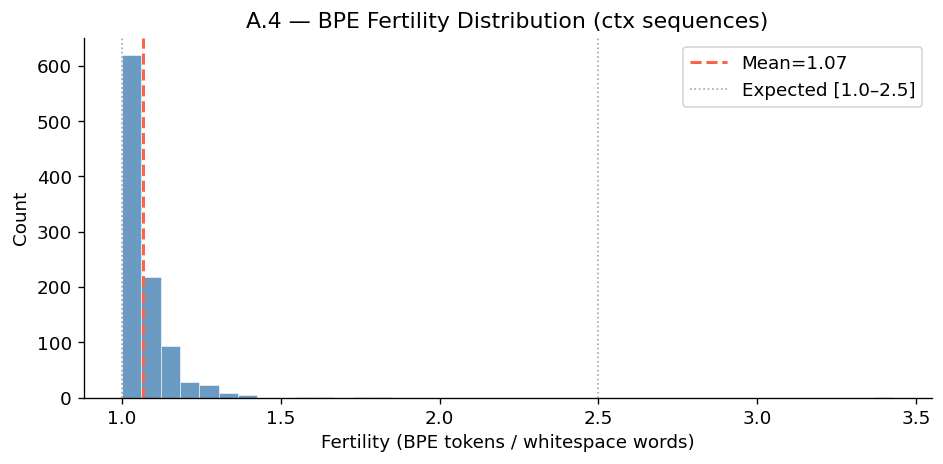

In [5]:
# === SECTION A.4: Fertility = #BPE_tokens / #whitespace_words ===
# We decode ctx IDs (from stage6_train_ids.jsonl) back to text via sp.decode(),
# then count whitespace words vs token count.

if not _require(TRAIN_JSONL, 'stage6_train_ids.jsonl'):
    raise SystemExit('Missing train JSONL')

fertilites = []
n_sample = 1000

with open(TRAIN_JSONL, encoding='utf-8') as f:
    sample_recs = []
    for i, line in enumerate(f):
        if i >= n_sample * 3:  # read ahead to allow random sample
            break
        sample_recs.append(json.loads(line))

selected = random.sample(sample_recs, min(n_sample, len(sample_recs)))

for rec in selected:
    ctx_ids = rec.get('ctx', [])
    if not ctx_ids:
        continue
    # Decode: sp.decode() expects list of ints
    # Filter out special tokens that aren't real subwords before decoding
    decodable = [tid for tid in ctx_ids if tid >= 4]  # skip pad/unk/sos/eos
    if not decodable:
        continue
    decoded_text = sp.decode(decodable)
    n_words  = len(decoded_text.split())
    n_tokens = len(ctx_ids)
    if n_words > 0:
        fertilites.append(n_tokens / n_words)

fert = np.array(fertilites)
t = Table(title=f'Fertility Analysis ({len(fert)} ctx sequences)', box=box.SIMPLE_HEAVY)
for metric, val in [
    ('Mean', f'{fert.mean():.3f}'),
    ('Median', f'{np.median(fert):.3f}'),
    ('Std', f'{fert.std():.3f}'),
    ('Min', f'{fert.min():.3f}'),
    ('Max', f'{fert.max():.3f}'),
    ('p5', f'{np.percentile(fert,5):.3f}'),
    ('p95', f'{np.percentile(fert,95):.3f}'),
    ('Expected range', '1.0 – 2.5'),
]:
    t.add_row(metric, str(val))
console.print(t)

ok_range = (1.0 <= fert.mean() <= 2.5)
console.print(f'Mean fertility in expected range [1.0–2.5]: '
              f'[bold {"green" if ok_range else "red"}]{"YES" if ok_range else "NO"}[/bold {"green" if ok_range else "red"}]')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.clip(fert, 0, 5), bins=40, color='steelblue', alpha=0.8, edgecolor='white', linewidth=0.4)
ax.axvline(fert.mean(), color='tomato', lw=1.8, ls='--', label=f'Mean={fert.mean():.2f}')
ax.axvline(1.0, color='gray', lw=1, ls=':', alpha=0.7)
ax.axvline(2.5, color='gray', lw=1, ls=':', alpha=0.7, label='Expected [1.0–2.5]')
ax.set_xlabel('Fertility (BPE tokens / whitespace words)')
ax.set_ylabel('Count')
ax.set_title('A.4 — BPE Fertility Distribution (ctx sequences)')
ax.legend()
fig.tight_layout()
_save_fig(fig, 'a4_fertility')
plt.show()


In [6]:
# === NUMERICAL SUMMARY: Fertility band distribution ===
t_fb = Table(title='Fertility Band Distribution', box=box.SIMPLE_HEAVY)
t_fb.add_column('Fertility range'); t_fb.add_column('Count', justify='right'); t_fb.add_column('%', justify='right')
for _label, _lo, _hi in [('<1.0',0,1.0),('1.0–1.5',1.0,1.5),('1.5–2.0',1.5,2.0),
                           ('2.0–2.5',2.0,2.5),('>2.5',2.5,999)]:
    _cnt = int(((fert>=_lo)&(fert<_hi)).sum())
    t_fb.add_row(_label, f'{_cnt:,}', f'{100*_cnt/len(fert):.1f}%')
console.print(t_fb)
console.print(f'[bold]% in healthy range [1.0–2.5]:[/bold] '
              f'{100*((fert>=1.0)&(fert<=2.5)).mean():.1f}%')


    Fertility Band Distribution    
                                   
  Fertility range   Count       %  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  <1.0                  0    0.0%  
  1.0–1.5             995   99.5%  
  1.5–2.0               4    0.4%  
  2.0–2.5               0    0.0%  
  >2.5                  1    0.1%

% in healthy range [1.0–2.5]: 99.9%

## A.5 — UNK (id=1) Rate per Split

In [7]:
# === SECTION A.5: UNK (id=1) occurrences per split ===

t = Table(title='UNK Rate per Split', box=box.ROUNDED)
t.add_column('Split', style='cyan')
t.add_column('UNK count', justify='right')
t.add_column('Total tokens', justify='right')
t.add_column('UNK rate', justify='right')
t.add_column('Assessment', justify='center')

for split_name, fpath in [('train', TRAIN_JSONL), ('val', VAL_JSONL), ('test', TEST_JSONL)]:
    if not fpath.exists():
        t.add_row(split_name, 'MISSING', '—', '—', '—')
        continue
    unk_cnt = 0
    total_cnt = 0
    with open(fpath, encoding='utf-8') as f:
        for line in f:
            rec = json.loads(line)
            for seq in (rec.get('ctx', []), rec.get('resp', [])):
                unk_cnt   += seq.count(UNK_ID)
                total_cnt += len(seq)
    rate = unk_cnt / total_cnt if total_cnt > 0 else 0
    assess = ('[bold green]Excellent[/bold green]' if rate < 0.001 else
              '[green]Good[/green]' if rate < 0.01 else
              '[yellow]Moderate[/yellow]' if rate < 0.05 else
              '[bold red]High — investigate[/bold red]')
    t.add_row(split_name, f'{unk_cnt:,}', f'{total_cnt:,}', f'{rate:.4%}', assess)
console.print(t)


                     UNK Rate per Split                     
╭───────┬───────────┬──────────────┬──────────┬────────────╮
│ Split │ UNK count │ Total tokens │ UNK rate │ Assessment │
├───────┼───────────┼──────────────┼──────────┼────────────┤
│ train │         0 │  105,623,620 │  0.0000% │ Excellent  │
│ val   │         0 │    4,989,365 │  0.0000% │ Excellent  │
│ test  │         0 │    5,077,426 │  0.0000% │ Excellent  │
╰───────┴───────────┴──────────────┴──────────┴────────────╯

## A.6 — Placeholder Token Usage

In [8]:
# === SECTION A.6: Placeholder token counts per split ===

# Look up placeholder IDs dynamically via sp.piece_to_id()
PLACEHOLDERS = ['▁__url__', '▁__path__', '▁__ip__', '▁__eot__', '▁__user__']
ph_ids = {tok: sp.piece_to_id(tok) for tok in PLACEHOLDERS}
console.print('Placeholder token IDs:', ph_ids)

# Count across splits
split_files = [('train', TRAIN_JSONL), ('val', VAL_JSONL), ('test', TEST_JSONL)]
split_counts = {}  # split -> {tok: count}
split_pairs  = {}  # split -> n_pairs

for split_name, fpath in split_files:
    counts = {tok: 0 for tok in PLACEHOLDERS}
    n_pairs = 0
    if not fpath.exists():
        split_counts[split_name] = counts
        split_pairs[split_name] = 0
        continue
    with open(fpath, encoding='utf-8') as f:
        for line in f:
            rec = json.loads(line)
            n_pairs += 1
            all_ids = rec.get('ctx', []) + rec.get('resp', [])
            for tok in PLACEHOLDERS:
                counts[tok] += all_ids.count(ph_ids[tok])
    split_counts[split_name] = counts
    split_pairs[split_name]  = n_pairs

t = Table(title='Placeholder Token Usage per Split', box=box.ROUNDED)
t.add_column('Token', style='cyan')
t.add_column('ID', justify='right')
for sn, _ in split_files:
    t.add_column(f'{sn}', justify='right')
    t.add_column(f'{sn}/pair', justify='right')

for tok in PLACEHOLDERS:
    row = [tok, str(ph_ids[tok])]
    for sn, _ in split_files:
        cnt = split_counts[sn][tok]
        n_p = split_pairs[sn]
        avg = f'{cnt/n_p:.3f}' if n_p > 0 else '—'
        row += [f'{cnt:,}', avg]
    t.add_row(*row)
console.print(t)


Placeholder token IDs:
{'▁__url__': 4, '▁__path__': 5, '▁__ip__': 6, '▁__eot__': 7, '▁__user__': 8}

                          Placeholder Token Usage per Split                           
╭───────────┬────┬───────────┬────────────┬─────────┬──────────┬─────────┬───────────╮
│ Token     │ ID │     train │ train/pair │     val │ val/pair │    test │ test/pair │
├───────────┼────┼───────────┼────────────┼─────────┼──────────┼─────────┼───────────┤
│ ▁__url__  │  4 │   238,190 │      0.223 │  13,205 │    0.276 │  14,153 │     0.296 │
│ ▁__path__ │  5 │   680,604 │      0.636 │  30,859 │    0.646 │  33,225 │     0.695 │
│ ▁__ip__   │  6 │    31,078 │      0.029 │   1,856 │    0.039 │   1,832 │     0.038 │
│ ▁__eot__  │  7 │ 3,345,605 │      3.125 │ 146,712 │    3.070 │ 147,355 │     3.082 │
│ ▁__user__ │  8 │    31,046 │      0.029 │   1,413 │    0.030 │   1,504 │     0.031 │
╰───────────┴────┴───────────┴────────────┴─────────┴──────────┴─────────┴───────────╯

## A.7 — Token Frequency Distribution

Building token frequency counter from train split...

Unique tokens in train: 31,901

Total tokens in train:  105,623,620

Saved → C:\git\nlp-final-project\notebooks\visualizations\a7_token_freq_dist.png

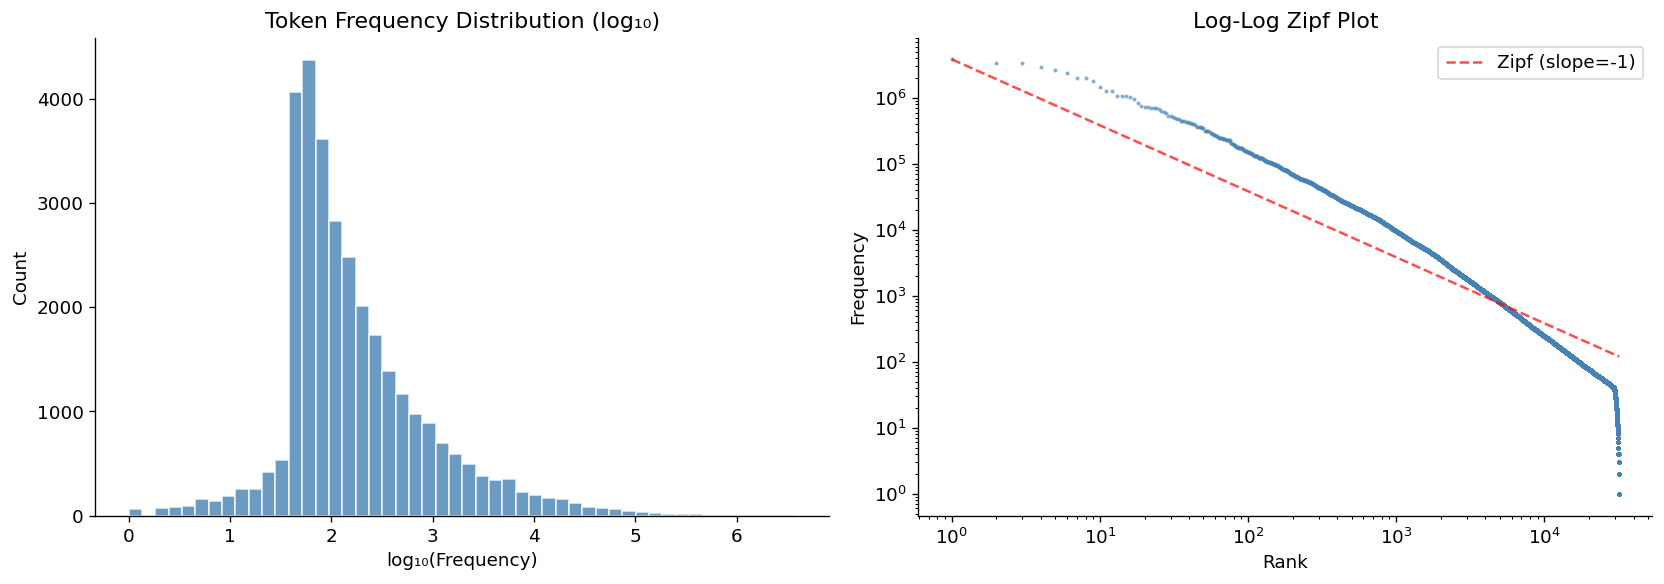

In [9]:
# === SECTION A.7: Token Counter from train ctx+resp; log histogram + Zipf ===

console.print('[bold]Building token frequency counter from train split...[/bold]')
token_counter = Counter()
with open(TRAIN_JSONL, encoding='utf-8') as f:
    for line in f:
        rec = json.loads(line)
        token_counter.update(rec.get('ctx', []))
        token_counter.update(rec.get('resp', []))

console.print(f'Unique tokens in train: {len(token_counter):,}')
console.print(f'Total tokens in train:  {sum(token_counter.values()):,}')

freqs = np.array(sorted(token_counter.values(), reverse=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log histogram
ax = axes[0]
log_freqs = np.log10(freqs[freqs > 0])
ax.hist(log_freqs, bins=50, color='steelblue', alpha=0.8, edgecolor='white')
ax.set_xlabel('log₁₀(Frequency)')
ax.set_ylabel('Count')
ax.set_title('Token Frequency Distribution (log₁₀)')

# Log-log Zipf
ax2 = axes[1]
ranks = np.arange(1, len(freqs) + 1)
ax2.loglog(ranks, freqs, 'o', markersize=1.5, alpha=0.5, color='steelblue')
# Zipf reference line
zipf_ref = freqs[0] / ranks
ax2.loglog(ranks, zipf_ref, 'r--', lw=1.5, alpha=0.7, label='Zipf (slope=-1)')
ax2.set_xlabel('Rank')
ax2.set_ylabel('Frequency')
ax2.set_title('Log-Log Zipf Plot')
ax2.legend()

fig.tight_layout()
_save_fig(fig, 'a7_token_freq_dist')
plt.show()


In [10]:
# === NUMERICAL SUMMARY: Token frequency statistics ===
t_tf = Table(title='Token Frequency Statistics', box=box.SIMPLE_HEAVY)
t_tf.add_column('Metric'); t_tf.add_column('Value', justify='right')
for _m, _v in [('Unique tokens', f'{len(token_counter):,}'),
               ('Total tokens',  f'{sum(token_counter.values()):,}'),
               ('Rank-1 freq',   f'{freqs[0]:,}'),
               ('Rank-100 freq', f'{freqs[99]:,}'),
               ('Median freq',   f'{np.median(freqs):.0f}'),
               ('Min freq',      f'{freqs[-1]:,}')]:
    t_tf.add_row(_m, _v)
console.print(t_tf)

_total_tok = sum(token_counter.values())
t_top = Table(title='Top-20 Most Frequent Tokens (train)', box=box.SIMPLE_HEAVY)
t_top.add_column('Rank', justify='right'); t_top.add_column('ID', justify='right')
t_top.add_column('Piece'); t_top.add_column('Freq', justify='right'); t_top.add_column('% total', justify='right')
for _rank, (_tid, _freq) in enumerate(token_counter.most_common(20), 1):
    _piece = sp.id_to_piece(int(_tid)) if int(_tid) < sp.GetPieceSize() else str(_tid)
    t_top.add_row(str(_rank), str(_tid), _piece, f'{_freq:,}', f'{100*_freq/_total_tok:.3f}%')
console.print(t_top)

t_cov = Table(title='Vocabulary Coverage by Min-Frequency Threshold', box=box.SIMPLE_HEAVY)
t_cov.add_column('Min freq'); t_cov.add_column('# tokens', justify='right')
t_cov.add_column('% vocab', justify='right'); t_cov.add_column('% total tokens', justify='right')
for _thr in [1, 5, 10, 50, 100, 1000, 10000]:
    _n = int((freqs >= _thr).sum())
    _ts = float(freqs[freqs >= _thr].sum()) / freqs.sum() * 100
    t_cov.add_row(f'>={_thr}', f'{_n:,}', f'{100*_n/len(freqs):.1f}%', f'{_ts:.1f}%')
console.print(t_cov)


  Token Frequency Statistics   
                               
  Metric                Value  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Unique tokens        31,901  
  Total tokens    105,623,620  
  Rank-1 freq       3,837,131  
  Rank-100 freq       151,513  
  Median freq             112  
  Min freq                  1

       Top-20 Most Frequent Tokens (train)       
                                                 
  Rank      ID   Piece           Freq   % total  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
     1       9   ▁i         3,837,131    3.633%  
     2       7   ▁__eot__   3,345,605    3.167%  
     3      19   ▁the       3,331,275    3.154%  
     4      32   ▁.         2,885,636    2.732%  
     5      30   ▁to        2,689,713    2.547%  
     6      38   ▁it        2,386,789    2.260%  
     7      46   ▁is        2,002,388    1.896%  
     8      41   ▁you       1,987,723    1.882%  
     9      11   ▁a         1,779,562    1.685%  
    10      59   ▁and       1,456,668    1.379%  
    11      62   ▁that      1,265,163    1.198%  
    12      61   ▁not       1,256,963    1.190%  
    13       2   <sos>      1,070,445    1.013%  
    14       3   <eos>      1,070,445    1.013%  
    15      56   ▁do        1,050,148    0.994%  
    16      43   ▁in        1,024,559    0.970%  
    17      72   ▁have        973,165    0.921%  
    18   31983   -            824,865    0.781%  
    19      66   ▁on          759,924    0.719%  
    20      81   ▁for         738,591    0.699%

  Vocabulary Coverage by Min-Frequency Threshold  
                                                  
  Min freq   # tokens   % vocab   % total tokens  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  >=1          31,901    100.0%           100.0%  
  >=5          31,592     99.0%           100.0%  
  >=10         31,225     97.9%           100.0%  
  >=50         26,198     82.1%            99.8%  
  >=100        17,069     53.5%            99.2%  
  >=1000        4,302     13.5%            95.5%  
  >=10000         968      3.0%            85.8%

## A.8 — Top-50 Most Frequent Pieces

In [11]:
# === SECTION A.8: Top-50 most frequent pieces ===

def _piece_type(piece: str) -> str:
    if piece.startswith('<') or piece.startswith('__'):
        return 'special'
    elif piece.startswith('\u2581'):  # ▁
        return 'word-initial'
    else:
        return 'subword'

t = Table(title='Top-50 Most Frequent Pieces (train)', box=box.ROUNDED, show_lines=False)
t.add_column('Rank', justify='right', style='dim')
t.add_column('Token ID', justify='right')
t.add_column('Piece', style='cyan')
t.add_column('Frequency', justify='right')
t.add_column('Type', style='yellow')

for rank, (tok_id, freq) in enumerate(token_counter.most_common(50), 1):
    piece = sp.id_to_piece(tok_id) if tok_id < sp.GetPieceSize() else f'<id={tok_id}>'
    ptype = _piece_type(piece)
    color = {'special': 'magenta', 'word-initial': 'green', 'subword': 'white'}[ptype]
    t.add_row(str(rank), str(tok_id), f'[{color}]{piece}[/{color}]', f'{freq:,}', ptype)
console.print(t)


           Top-50 Most Frequent Pieces (train)            
╭──────┬──────────┬───────────┬───────────┬──────────────╮
│ Rank │ Token ID │ Piece     │ Frequency │ Type         │
├──────┼──────────┼───────────┼───────────┼──────────────┤
│    1 │        9 │ ▁i        │ 3,837,131 │ word-initial │
│    2 │        7 │ ▁__eot__  │ 3,345,605 │ word-initial │
│    3 │       19 │ ▁the      │ 3,331,275 │ word-initial │
│    4 │       32 │ ▁.        │ 2,885,636 │ word-initial │
│    5 │       30 │ ▁to       │ 2,689,713 │ word-initial │
│    6 │       38 │ ▁it       │ 2,386,789 │ word-initial │
│    7 │       46 │ ▁is       │ 2,002,388 │ word-initial │
│    8 │       41 │ ▁you      │ 1,987,723 │ word-initial │
│    9 │       11 │ ▁a        │ 1,779,562 │ word-initial │
│   10 │       59 │ ▁and      │ 1,456,668 │ word-initial │
│   11 │       62 │ ▁that     │ 1,265,163 │ word-initial │
│   12 │       61 │ ▁not      │ 1,256,963 │ word-initial │
│   13 │        2 │ <sos>     │ 1,070,445 │ special      │
│   14 │        3 │ <eos>     │ 1,070,445 │ special      │
│   15 │       56 │ ▁do       │ 1,050,148 │ word-initial │
│   16 │       43 │ ▁in       │ 1,024,559 │ word-initial │
│   17 │       72 │ ▁have     │   973,165 │ word-initial │
│   18 │    31983 │ -         │   824,865 │ subword      │
│   19 │       66 │ ▁on       │   759,924 │ word-initial │
│   20 │       81 │ ▁for      │   738,591 │ word-initial │
│   21 │       89 │ ▁what     │   725,156 │ word-initial │
│   22 │       74 │ ▁can      │   712,222 │ word-initial │
│   23 │       86 │ ▁of       │   699,030 │ word-initial │
│   24 │       95 │ ▁but      │   698,541 │ word-initial │
│   25 │        5 │ ▁__path__ │   680,604 │ word-initial │
│   26 │      100 │ ▁my       │   637,760 │ word-initial │
│   27 │       99 │ ▁with     │   616,466 │ word-initial │
│   28 │    31986 │ '         │   590,996 │ subword      │
│   29 │      119 │ ▁if       │   536,999 │ word-initial │
│   30 │      126 │ ▁ubuntu   │   536,253 │ word-initial │
│   31 │      124 │ ▁how      │   519,854 │ word-initial │
│   32 │      135 │ ▁are      │   492,662 │ word-initial │
│   33 │      115 │ ▁-        │   486,029 │ word-initial │
│   34 │      137 │ ▁just     │   484,814 │ word-initial │
│   35 │      138 │ ▁or       │   453,551 │ word-initial │
│   36 │       84 │ ▁be       │   444,263 │ word-initial │
│   37 │      151 │ ▁there    │   438,913 │ word-initial │
│   38 │      142 │ ▁am       │   437,743 │ word-initial │
│   39 │       91 │ ▁install  │   435,761 │ word-initial │
│   40 │      152 │ ▁your     │   420,197 │ word-initial │
│   41 │      157 │ ▁this     │   413,967 │ word-initial │
│   42 │      160 │ ▁will     │   407,074 │ word-initial │
│   43 │      134 │ ▁so       │   401,097 │ word-initial │
│   44 │      117 │ ▁me       │   391,059 │ word-initial │
│   45 │      170 │ ▁from     │   361,439 │ word-initial │
│   46 │      163 │ ▁does     │   360,552 │ word-initial │
│   47 │      168 │ ▁use      │   360,199 │ word-initial │
│   48 │      171 │ ▁then     │   357,185 │ word-initial │
│   49 │      164 │ ▁no       │   355,257 │ word-initial │
│   50 │      156 │ ▁get      │   344,634 │ word-initial │
╰──────┴──────────┴───────────┴───────────┴──────────────╯

## Summary

In [12]:
# === SECTION SUMMARY: Rich panel ===

if _require(STAGE6_STATS, 'stage6_stats.json'):
    with open(STAGE6_STATS) as f:
        s6 = json.load(f)
else:
    s6 = {}

lines = [
    f'[bold cyan]SPM vocab size:[/bold cyan]      {sp.GetPieceSize():,}',
    f'[bold cyan]vocab.json size:[/bold cyan]     {len(vocab):,}',
    f'[bold cyan]Special pieces:[/bold cyan]      {n_special:,}',
    f'[bold cyan]Word-initial (▁):[/bold cyan]    {n_word_initial:,}',
    f'[bold cyan]Subword:[/bold cyan]             {n_subword:,}',
    f'[bold cyan]Mean fertility:[/bold cyan]      {fert.mean():.3f}  (expected 1.0–2.5)',
    f'[bold cyan]Unique train tokens:[/bold cyan] {len(token_counter):,}',
    f'[bold cyan]stage6 pairs — train:[/bold cyan] {s6.get("n_train","—")}  '
    f'val: {s6.get("n_val","—")}  test: {s6.get("n_test","—")}',
    f'[bold cyan]sos_id:[/bold cyan] {s6.get("sos_id",2)}   '
    f'[bold cyan]eos_id:[/bold cyan] {s6.get("eos_id",3)}',
]
console.print(Panel('\n'.join(lines), title='📋 Tokenizer Summary (Stages 5–6)', border_style='green'))


╭─────────────────────────────────────── 📋 Tokenizer Summary (Stages 5–6) ───────────────────────────────────────╮
│ SPM vocab size:      32,000                                                                                     │
│ vocab.json size:     32,000                                                                                     │
│ Special pieces:      10                                                                                         │
│ Word-initial (▁):    23,571                                                                                     │
│ Subword:             8,419                                                                                      │
│ Mean fertility:      1.067  (expected 1.0–2.5)                                                                  │
│ Unique train tokens: 31,901                                                                                     │
│ stage6 pairs — train: 1070445  val: 47791  test: 47805                                                          │
│ sos_id: 2   eos_id: 3                                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯